# **TikTok Project**
**Course 2 - Go Beyond the Numbers: Translate Data into Insights**

Your TikTok data team is still in the early stages of their latest project. So far, you’ve completed a project proposal and used Python to inspect and organize the TikTok dataset.

Orion Rainier, a Data Scientist at TikTok, is pleased with the work you have already completed and is requesting your assistance with some Exploratory Data Analysis (EDA) and data visualization. The management team asked to see a Python notebook showing data structuring and cleaning, as well as any matplotlib/seaborn visualizations plotted to help us understand the data. At the very least, include a graph comparing claim counts to opinion counts, as well as boxplots of the most important variables (like “video duration,” “video like count,” “video comment count,” and “video view count”) to check for outliers. Also, include a breakdown of “author ban status” counts.

Additionally, the management team has recently asked all EDA to include Tableau visualizations. Tableau visualizations are particularly helpful in status reports to the client and board members. For this data, create a Tableau dashboard showing a simple claims versus opinions count, as well as stacked bar charts of claims versus opinions for variables like video view counts, video like counts, video share counts, and video download counts. Make sure it is easy to understand to someone who isn’t data savvy, and remember that the assistant director is a person with visual impairments.

You also notice a follow-up email from the Data Science Lead, Willow Jaffey. Willow suggests including an executive summary of your analysis to share with teammates.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 2 End-of-course project: Exploratory data analysis**

In this activity, you will examine data provided and prepare it for analysis. You will also design a professional data visualization that tells a story, and will help data-driven decisions for business needs.

Please note that the Tableau visualization activity is optional, and will not affect your completion of the course. Completing the Tableau activity will help you practice planning out and plotting a data visualization based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.
<br/>

**The purpose** of this project is to conduct exploratory data analysis on a provided data set. Your mission is to continue the investigation you began in C1 and perform further EDA on this data with the aim of learning more about the variables. Of particular interest is information related to what distinguishes claim videos from opinion videos.

**The goal** is to explore the dataset and create visualizations.
<br/>
*This activity has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Build visualizations

**Part 4:** Evaluate and share results

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.

# **Visualize a story in Tableau and Python**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document and those below where applicable to craft your response:
1. Identify any outliers:


*   What methods are best for identifying outliers?
*   How do you make the decision to keep or exclude outliers from any future models?



I will identify outliers mainly with box plots, histograms, skewness, and the IQR rule. Because social media engagement data is often highly right-skewed, I will not automatically remove every extreme value. Instead, I will distinguish between:

- **legitimate high-performing videos** that are real but extreme, and  
- **problematic records** caused by missing data, impossible values, or data-entry issues.

For this project, the best approach is to:
1. inspect the distributions visually,  
2. quantify potential outliers with the IQR rule, and  
3. keep genuine extreme values for EDA while documenting them clearly for any future predictive modelling.

### **Task 1. Imports, links, and loading**
Go to Tableau Public
The following link will help you complete this activity. Keep Tableau Public open as you proceed to the next steps.

Link to supporting materials:
Public Tableau: https://public.tableau.com/s/. Note that the TikTok dataset can be downloaded directly from this notebook by going to "Lab Files" in the menu bar at the top of the page, clicking into the "/home/jovyan/work" folder, selecting `tiktok_dataset.csv`, and clicking "Download" above the list of files. 

For EDA of the data, import the packages that would be most helpful, such as `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`.


In [1]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

Then, load the dataset into a dataframe. Read in the data and store it as a dataframe object.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.


In [2]:
# Load dataset into dataframe
from pathlib import Path

possible_paths = [
    Path("tiktok_dataset.csv"),
    Path("/mnt/data/tiktok_dataset.csv")
]

for path in possible_paths:
    if path.exists():
        data = pd.read_csv(path)
        break
else:
    raise FileNotFoundError("Could not find tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document and those below where applicable to complete your code.

### **Task 2a: Data exploration and cleaning**

The first step is to assess your data. Check the Data Source page on Tableau Public to get a sense of the size, shape and makeup of the data set.

Consider functions that help you understand and structure the data.

*    `.head()`
*    `.info()`
*    `.describe()`
*    `.groupby()`
*    `.sort_values()`

Consider the following questions as you work:

What do you do about missing data (if any)?

Are there data outliers?

Start by discovering, using `.head()`, `.size`, and `.shape`.

In [3]:
# Display and examine the first few rows of the dataframe
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [4]:
data.size

232584

In [5]:
data.shape

(19382, 12)

Get basic information about the data, using `.info()`.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


There are 7 columns that have missing values

In [7]:
# Missing-value summary
missing_by_column = data.isnull().sum().sort_values(ascending=False)
missing_percent = (data.isnull().mean() * 100).round(2)

display(pd.DataFrame({
    'missing_count': missing_by_column,
    'missing_percent': missing_percent[missing_by_column.index]
}))

total_missing_values = data.isnull().sum().sum()
print(f'Total missing values: {total_missing_values}')
print(f'Percent of all cells missing: {total_missing_values / data.size:.2%}')

Total missing values: 2086
percent total missing values 0.9%


In [8]:
# Generate a table of descriptive statistics
display(data.describe())
display(data.describe(include='object'))

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


I will drop `#` and `video_id` because they are identifier fields and do not add analytical value for EDA.  
I will also remove rows with missing values because the missingness is small (about 1.5% in the affected columns), and the missing values occur in key fields such as `claim_status` and the engagement metrics, which makes those rows difficult to analyse reliably.

In [9]:
# Drop irrelevant identifier columns
data_clean = data.drop(columns=['#', 'video_id']).copy()

In [10]:
# Delete rows with missing values
data_clean = data_clean.dropna().copy()

In [11]:
print('Shape after cleaning:', data_clean.shape)
print('Remaining missing values:', data_clean.isnull().sum().sum())

190840

Checking for duplicate values, I dont think there will be any, but its good to check.

In [12]:
# Check duplicate rows
num_duplicates = data_clean.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicates}')

number of duplicate values: 0


In [13]:
# Define a function to detect outliers using the IQR rule
def outliers(column, multiplier=1.5):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    return lower, upper

Select data visualization types that will help you understand and explain the data.

Now that you know which data columns you’ll use, it is time to decide which data visualization makes the most sense for EDA of the TikTok dataset. What type of data visualization(s) would be most helpful? Consider the distribution of the data.

* Line graph
* Bar chart
* Box plot
* Histogram
* Heat map
* Scatter plot
* A geographic map


The most helpful visualisations for this dataset are:

- **Box plots** to quickly identify skewness and potential outliers in numeric engagement variables  
- **Histograms** to understand the shape of each distribution  
- **Count plots** for comparing categorical variables such as claim status, verification status, and ban status  
- **Bar plots** of medians to compare typical performance across groups  
- **Pie chart** to show the share of total views by claim status  
- **Scatterplots** to explore the relationship between views and likes, especially by claim status

These charts work well because the dataset mixes categorical labels with heavily skewed numeric engagement metrics.

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3. Build visualizations**

Now that you have assessed your data, it’s time to plot your visualization(s).

#### **video_duration_sec**

Create a box plot to examine the spread of values in the `video_duration_sec` column.

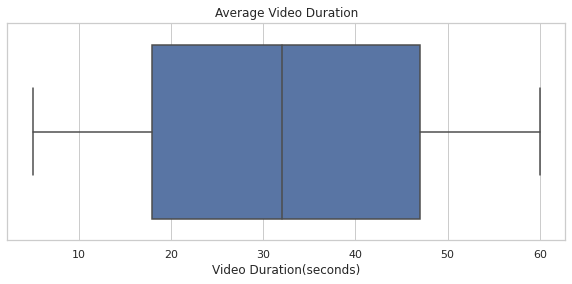

In [14]:
# Box plot: video_duration_sec
plt.figure(figsize=(10, 4))
sns.boxplot(x=data_clean['video_duration_sec'])
plt.title('Distribution of Video Duration')
plt.xlabel('Video duration (seconds)')
plt.show()

Create a histogram of the values in the `video_duration_sec` column to further explore the distribution of this variable.

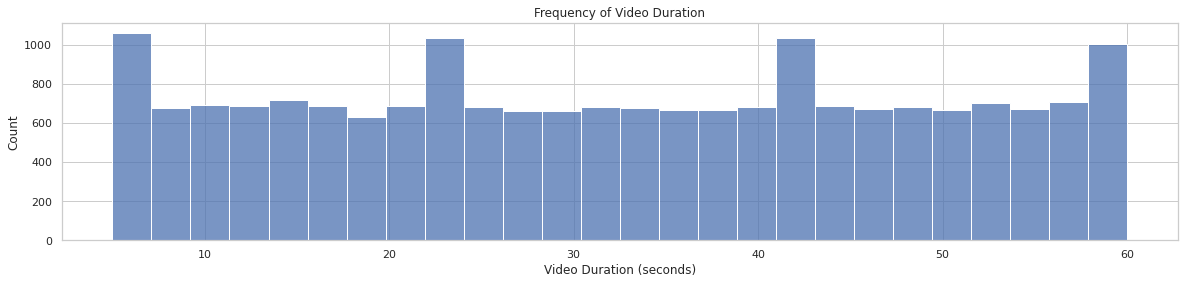

In [15]:
# Histogram: video_duration_sec
plt.figure(figsize=(12, 4))
plt.hist(data_clean['video_duration_sec'], bins=30)
plt.title('Histogram of Video Duration')
plt.xlabel('Video duration (seconds)')
plt.ylabel('Frequency')
plt.show()

#### **video_view_count**

Create a box plot to examine the spread of values in the `video_view_count` column.

count     19084.000000
mean     254708.558688
std      322893.280814
min          20.000000
25%        4942.500000
50%        9954.500000
75%      504327.000000
max      999817.000000
Name: video_view_count, dtype: float64

0.9284609317008538

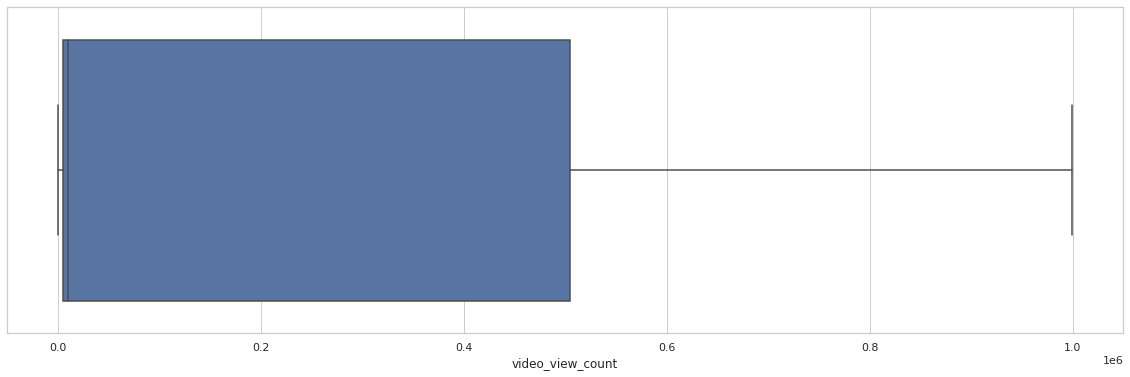

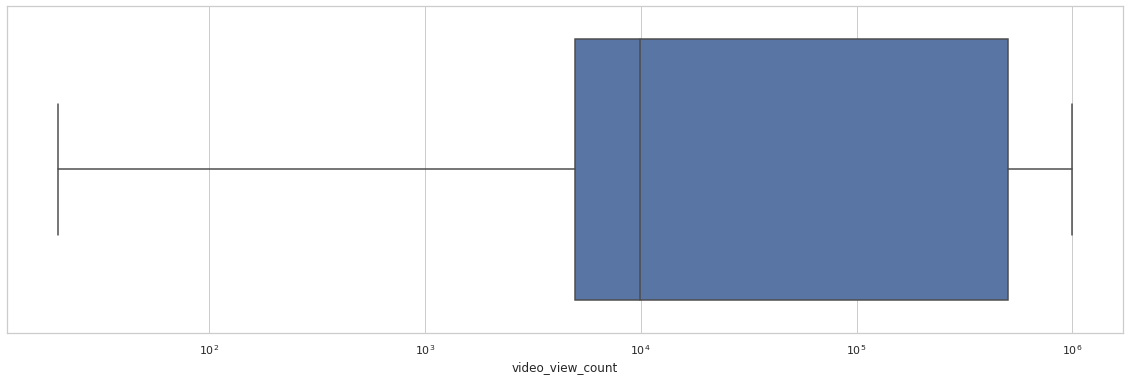

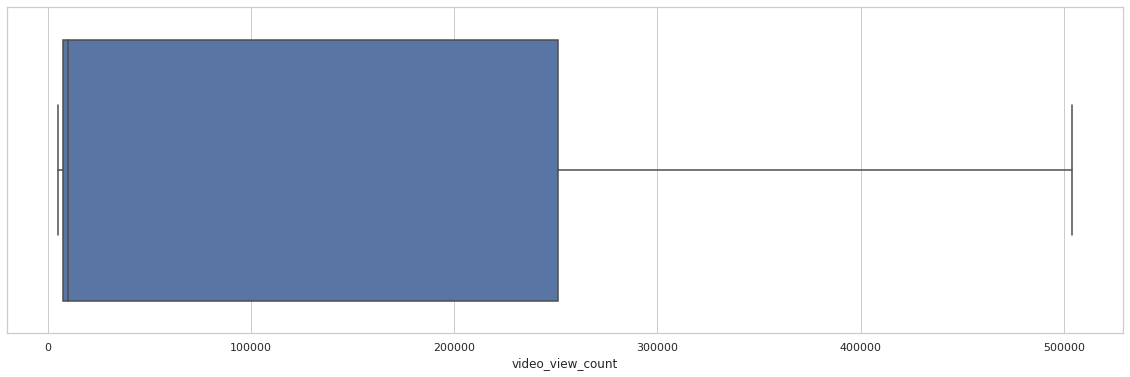

In [16]:
# Box plots: video_view_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.boxplot(x=data_clean['video_view_count'], ax=axes[0])
axes[0].set_title('Video View Count')
axes[0].set_xlabel('Views')

sns.boxplot(x=np.log1p(data_clean['video_view_count']), ax=axes[1])
axes[1].set_title('Log-Scaled Video View Count')
axes[1].set_xlabel('log(1 + views)')

plt.tight_layout()
plt.show()

Create a histogram of the values in the `video_view_count` column to further explore the distribution of this variable.

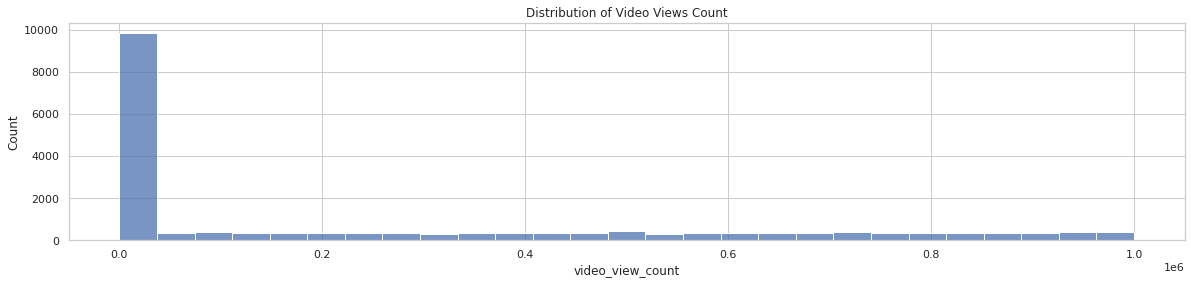

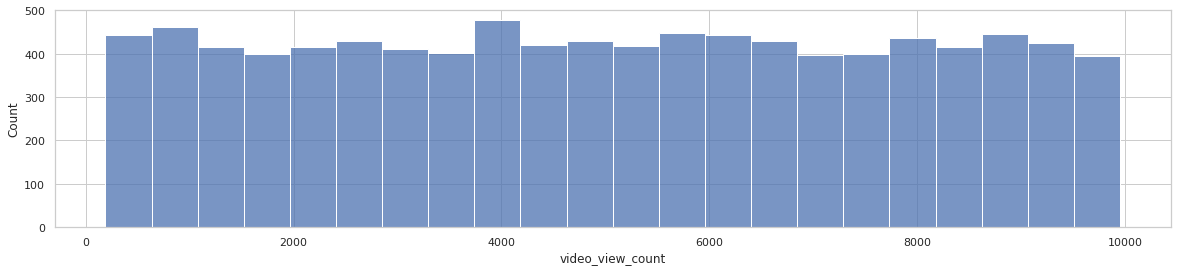

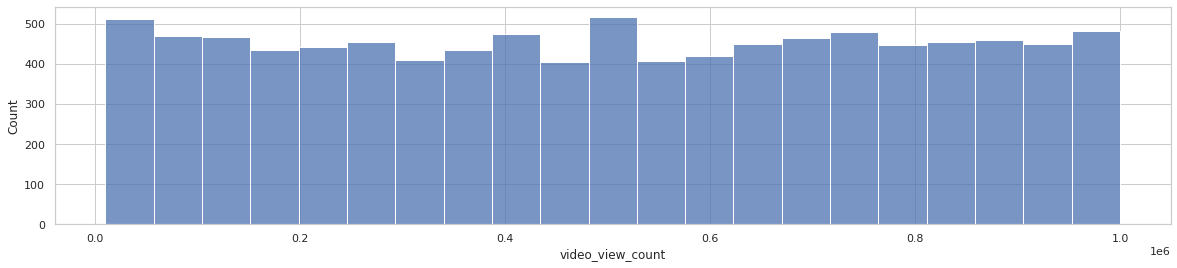

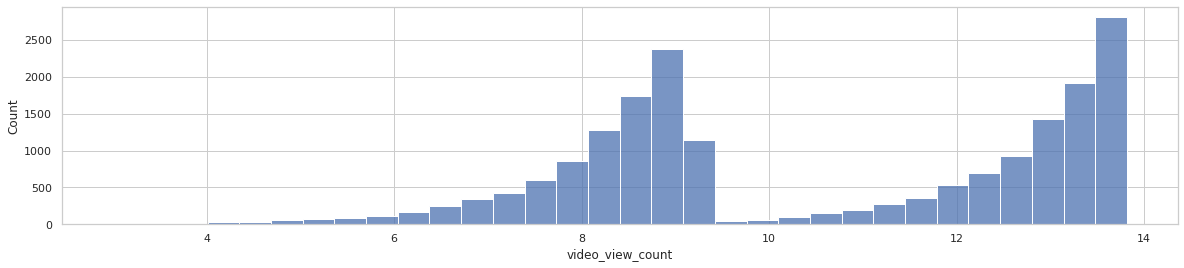

In [17]:
# Histograms: video_view_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data_clean['video_view_count'], bins=40)
axes[0].set_title('Histogram of Video View Count')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(data_clean['video_view_count']), bins=40)
axes[1].set_title('Histogram of Log-Scaled Video View Count')
axes[1].set_xlabel('log(1 + views)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`video_view_count` is strongly right-skewed. Most videos have relatively low to moderate view counts, while a smaller group receives very high numbers of views. The log-scaled histogram makes this pattern easier to see and suggests that extremely popular videos are stretching the distribution.

#### **video_like_count**

Create a box plot to examine the spread of values in the `video_like_count` column.

810.75

125020.0

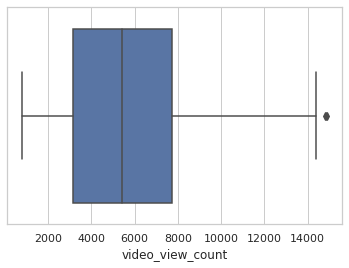

In [18]:
# Box plots: video_like_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.boxplot(x=data_clean['video_like_count'], ax=axes[0])
axes[0].set_title('Video Like Count')
axes[0].set_xlabel('Likes')

sns.boxplot(x=np.log1p(data_clean['video_like_count']), ax=axes[1])
axes[1].set_title('Log-Scaled Video Like Count')
axes[1].set_xlabel('log(1 + likes)')

plt.tight_layout()
plt.show()

Create a histogram of the values in the `video_like_count` column to further explore the distribution of this variable.

In [ ]:
# Histograms: video_like_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data_clean['video_like_count'], bins=40)
axes[0].set_title('Histogram of Video Like Count')
axes[0].set_xlabel('Likes')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(data_clean['video_like_count']), bins=40)
axes[1].set_title('Histogram of Log-Scaled Video Like Count')
axes[1].set_xlabel('log(1 + likes)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`video_like_count` is also heavily right-skewed with many high-end values. This suggests that likes are concentrated among a relatively small number of videos, which is common in viral social media content.

#### **video_comment_count**

Create a box plot to examine the spread of values in the `video_comment_count` column.

In [ ]:
# Box plots: video_comment_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.boxplot(x=data_clean['video_comment_count'], ax=axes[0])
axes[0].set_title('Video Comment Count')
axes[0].set_xlabel('Comments')

sns.boxplot(x=np.log1p(data_clean['video_comment_count']), ax=axes[1])
axes[1].set_title('Log-Scaled Video Comment Count')
axes[1].set_xlabel('log(1 + comments)')

plt.tight_layout()
plt.show()

Create a histogram of the values in the `video_comment_count` column to further explore the distribution of this variable.

In [ ]:
# Histograms: video_comment_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data_clean['video_comment_count'], bins=40)
axes[0].set_title('Histogram of Video Comment Count')
axes[0].set_xlabel('Comments')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(data_clean['video_comment_count']), bins=40)
axes[1].set_title('Histogram of Log-Scaled Video Comment Count')
axes[1].set_xlabel('log(1 + comments)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`video_comment_count` is very strongly right-skewed. Most videos receive few comments, while a smaller number attract exceptionally high discussion. This makes comments one of the most unevenly distributed engagement measures in the dataset.

#### **video_share_count**

Create a box plot to examine the spread of values in the `video_share_count` column.

In [ ]:
# Box plots: video_share_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.boxplot(x=data_clean['video_share_count'], ax=axes[0])
axes[0].set_title('Video Share Count')
axes[0].set_xlabel('Shares')

sns.boxplot(x=np.log1p(data_clean['video_share_count']), ax=axes[1])
axes[1].set_title('Log-Scaled Video Share Count')
axes[1].set_xlabel('log(1 + shares)')

plt.tight_layout()
plt.show()

*Create* a histogram of the values in the `video_share_count` column to further explore the distribution of this variable.

In [ ]:
# Histograms: video_share_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data_clean['video_share_count'], bins=40)
axes[0].set_title('Histogram of Video Share Count')
axes[0].set_xlabel('Shares')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(data_clean['video_share_count']), bins=40)
axes[1].set_title('Histogram of Log-Scaled Video Share Count')
axes[1].set_xlabel('log(1 + shares)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`video_share_count` is positively skewed, with most videos having relatively low share counts and a smaller number spreading widely. This suggests shares may be a useful signal of unusually high-performing or highly amplified content.

#### **video_download_count**

Create a box plot to examine the spread of values in the `video_download_count` column.

In [ ]:
# Box plots: video_download_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.boxplot(x=data_clean['video_download_count'], ax=axes[0])
axes[0].set_title('Video Download Count')
axes[0].set_xlabel('Downloads')

sns.boxplot(x=np.log1p(data_clean['video_download_count']), ax=axes[1])
axes[1].set_title('Log-Scaled Video Download Count')
axes[1].set_xlabel('log(1 + downloads)')

plt.tight_layout()
plt.show()

Create a histogram of the values in the `video_download_count` column to further explore the distribution of this variable.

In [ ]:
# Histograms: video_download_count
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data_clean['video_download_count'], bins=40)
axes[0].set_title('Histogram of Video Download Count')
axes[0].set_xlabel('Downloads')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(data_clean['video_download_count']), bins=40)
axes[1].set_title('Histogram of Log-Scaled Video Download Count')
axes[1].set_xlabel('log(1 + downloads)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`video_download_count` is right-skewed as well. Most videos are downloaded only a small number of times, but a smaller group is downloaded far more often. This may reflect content that users want to save or reuse.

#### **Claim status by verification status**

Now, create a histogram with four bars: one for each combination of claim status and verification status.

In [ ]:
# Claim status by verification status
verification_claim = pd.crosstab(data_clean['claim_status'], data_clean['verified_status'])
verification_claim.plot(kind='bar', figsize=(10, 5))
plt.title('Claim Status by Verification Status')
plt.xlabel('Claim status')
plt.ylabel('Number of videos')
plt.xticks(rotation=0)
plt.show()

display(pd.crosstab(data_clean['verified_status'], data_clean['claim_status']))
display((pd.crosstab(data_clean['verified_status'], data_clean['claim_status'], normalize='index') * 100).round(2))

There are far more unverified users than verified users in the dataset. Among verified users, opinion videos are much more common than claim videos. Among unverified users, claim videos make up a slightly larger share. This suggests verified users are less likely to post claims and more likely to post opinions.

#### **Claim status by author ban status**

The previous course used a `groupby()` statement to examine the count of each claim status for each author ban status. Now, use a histogram to communicate the same information.

In [ ]:
# Claim status by author ban status
ban_claim = pd.crosstab(data_clean['author_ban_status'], data_clean['claim_status']).reindex(
    ['active', 'under review', 'banned']
)
ban_claim.plot(kind='bar', figsize=(10, 5))
plt.title('Claim Status by Author Ban Status')
plt.xlabel('Author ban status')
plt.ylabel('Number of videos')
plt.xticks(rotation=0)
plt.show()

display(pd.crosstab(data_clean['author_ban_status'], data_clean['claim_status']))
display((pd.crosstab(data_clean['author_ban_status'], data_clean['claim_status'], normalize='index') * 100).round(2))

Active authors are much more common overall than banned authors. However, banned and under-review authors are disproportionately associated with claim videos, while active authors post more opinion videos. This suggests claim content may be more likely to be linked with moderation risk.

#### **Median view counts by ban status**

Create a bar plot with three bars: one for each author ban status. The height of each bar should correspond with the median number of views for all videos with that author ban status.

In [ ]:
# Median view counts by ban status
median_views_by_ban = (
    data_clean.groupby('author_ban_status')['video_view_count']
    .median()
    .reindex(['active', 'under review', 'banned'])
)

plt.figure(figsize=(8, 5))
plt.bar(median_views_by_ban.index, median_views_by_ban.values)
plt.title('Median Video Views by Author Ban Status')
plt.xlabel('Author ban status')
plt.ylabel('Median views')
plt.show()

median_views_by_ban

Videos from non-active authors have much higher median view counts than videos from active authors. In particular, banned and under-review authors have dramatically higher typical view counts. Based on that pattern, `video_view_count` appears to be a strong candidate indicator of claim status.

In [ ]:
# Calculate the median view count for claim status
data_clean.groupby('claim_status')['video_view_count'].median()

In [ ]:
# Compare median engagement metrics by claim status
data_clean.groupby('claim_status')[
    ['video_view_count', 'video_like_count', 'video_share_count',
     'video_download_count', 'video_comment_count']
].median()

#### **Total views by claim status**

Create a pie graph that depicts the proportions of total views for claim videos and total views for opinion videos.

In [ ]:
# Total views by claim status
total_views = data_clean.groupby('claim_status')['video_view_count'].sum()

plt.figure(figsize=(7, 7))
plt.pie(total_views, labels=total_views.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of Total Views by Claim Status')
plt.show()

total_views

Claim videos account for an overwhelming majority of total views in the dataset. Even though the number of claim and opinion videos is fairly similar, claims receive vastly more attention overall. That makes claim-related content especially important for platform monitoring.

### **Task 4. Determine outliers**

When building predictive models, the presence of outliers can be problematic. For example, if you were trying to predict the view count of a particular video, videos with extremely high view counts might introduce bias to a model. Also, some outliers might indicate problems with how data was captured or recorded.

The ultimate objective of the TikTok project is to build a model that predicts whether a video is a claim or opinion. The analysis you've performed indicates that a video's engagement level is strongly correlated with its claim status. There's no reason to believe that any of the values in the TikTok data are erroneously captured, and they align with expectation of how social media works: a very small proportion of videos get super high engagement levels. That's the nature of viral content.

Nonetheless, it's good practice to get a sense of just how many of your data points could be considered outliers. The definition of an outlier can change based on the details of your project, and it helps to have domain expertise to decide a threshold. You've learned that a common way to determine outliers in a normal distribution is to calculate the interquartile range (IQR) and set a threshold that is 1.5 * IQR above the 3rd quartile.

In this TikTok dataset, the values for the count variables are not normally distributed. They are heavily skewed to the right. One way of modifying the outlier threshold is by calculating the **median** value for each variable and then adding 1.5 * IQR. This results in a threshold that is, in this case, much lower than it would be if you used the 3rd quartile.

Write a for loop that iterates over the column names of each count variable. For each iteration:
1. Calculate the IQR of the column
2. Calculate the median of the column
3. Calculate the outlier threshold (median + 1.5 * IQR)
4. Calculate the numer of videos with a count in that column that exceeds the outlier threshold
5. Print "Number of outliers, {column name}: {outlier count}"

```
Example:
Number of outliers, video_view_count: ___
Number of outliers, video_like_count: ___
Number of outliers, video_share_count: ___
Number of outliers, video_download_count: ___
Number of outliers, video_comment_count: ___
```

In [ ]:
# Determine outliers for numeric columns using the IQR rule
numeric_cols = [
    'video_duration_sec', 'video_view_count', 'video_like_count',
    'video_share_count', 'video_download_count', 'video_comment_count'
]

outlier_summary = []

for col in numeric_cols:
    lower, upper = outliers(data_clean[col])
    outlier_count = ((data_clean[col] < lower) | (data_clean[col] > upper)).sum()
    outlier_summary.append({
        'column': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outlier_count,
        'outlier_percent': round(outlier_count / len(data_clean) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_percent', ascending=False)
display(outlier_df)

#### **Scatterplot**

In [ ]:
# Scatterplot: video_view_count vs video_like_count by claim_status
plot_sample = data_clean.sample(min(len(data_clean), 5000), random_state=42)

plt.figure(figsize=(10, 6))
for status in plot_sample['claim_status'].unique():
    subset = plot_sample[plot_sample['claim_status'] == status]
    plt.scatter(subset['video_view_count'], subset['video_like_count'], alpha=0.5, label=status)

plt.title('Views vs Likes by Claim Status')
plt.xlabel('Video views')
plt.ylabel('Video likes')
plt.legend(title='Claim status')
plt.show()

In [ ]:
# Scatterplot: opinions only
opinions = data_clean[data_clean['claim_status'] == 'opinion'].sample(
    min((data_clean['claim_status'] == 'opinion').sum(), 5000), random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(opinions['video_view_count'], opinions['video_like_count'], alpha=0.5)
plt.title('Views vs Likes for Opinion Videos')
plt.xlabel('Video views')
plt.ylabel('Video likes')
plt.show()

You can do a scatterplot in Tableau Public as well, which can be easier to manipulate and present. If you'd like step by step instructions, you can review the instructions linked in the previous Activity page.

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 5a. Results and evaluation**

Having built visualizations in Tableau and in Python, what have you learned about the dataset? What other questions have your visualizations uncovered that you should pursue?

***Pro tip:*** Put yourself in your client's perspective, what would they want to know?

Use the following code cells to pursue any additional EDA. Also use the space to make sure your visualizations are clean, easily understandable, and accessible.

***Ask yourself:*** Did you consider color, contrast, emphasis, and labeling?


I have learned that this dataset is clean overall after removing a small amount of missing data, but the engagement variables are highly skewed and contain many extreme high-performing videos. Claim and opinion videos appear in similar numbers, yet claim videos attract dramatically more views, likes, comments, shares, and downloads. I also learned that verified users are much more likely to post opinions, whereas banned or under-review authors are much more likely to post claims.

My other questions are:
- What specific language patterns in the transcription text are associated with claim videos?
- Are claims more likely than opinions to go viral because of controversy, uncertainty, or misinformation?
- Which engagement metric is the best predictor of claim status in a classification model?
- Does video duration have any meaningful impact when analysed together with claim status?

My client would likely want to know which factors are most associated with potentially risky content, because that could help prioritise moderation and review workflows.

### **Task 5b. Conclusion**
*Make it professional and presentable*

You have visualized the data you need to share with the director now. Remember, the goal of a data visualization is for an audience member to glean the information on the chart in mere seconds.

*Questions to ask yourself for reflection:*
Why is it important to conduct Exploratory Data Analysis? What other visuals could you create?


EDA is important because it helps us understand data quality, identify missing values and unusual patterns, and detect relationships before modelling or making business decisions. In this dataset, EDA showed that engagement metrics are not normally distributed and that claim-related videos behave very differently from opinion videos.

Visualisations helped me understand the dataset by making the skewness, outliers, and category-level differences easy to see quickly. In particular, the count plots, bar plot, pie chart, and scatterplots made it clear that claim videos receive far more attention and are more strongly associated with banned or under-review authors.

**Actionable recommendations**
1. Prioritise moderation review for highly viewed claim videos, because they account for the vast majority of total views.
2. Use `video_view_count` and other engagement metrics as potential early-warning features in future predictive models.
3. Monitor unverified accounts more closely, since they post a higher share of claim content than verified users.
4. Investigate the transcription text next, because the language itself may help explain why claim videos spread more widely.

You’ve now completed a professional data visualization according to a business need. Well done! Be sure to save your work as a reference for later work in Tableau.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.